# 장외파생상품 기초실무 과제 {.unnumbered}

20249132 김형환

In [1]:
import pandas_market_calendars as mcal
from datetime import date
import numpy as np
import scipy.stats as sst
import matplotlib.pyplot as plt

In [2]:
exp_dd = date(2026, 3, 19); strt_dd = date(2025, 4, 29);
exptime = (exp_dd - strt_dd).days

strt = '2025-04-30'; end='2026-03-16'; nyse = mcal.get_calendar('NYSE');
timesteps = nyse.valid_days(start_date=strt, end_date=end)

print("Day to maturity is :",exptime)
print("Number of trading day(timestep) is :",len(timesteps))

Day to maturity is : 324
Number of trading day(timestep) is : 220


In [3]:
def DownAndOutPut_Price(s, k, r, q, t, sigma, n, b, m, rebate):
    # Set parameters
    dt = t/m
    dts = np.arange(dt, t+dt, dt)

    # (1) Stratified sampling, z_t makes price at T & z makes brownian bridge
    z_t = sst.norm.ppf((np.arange(n) + np.random.uniform(0,1,n)) / n)
    z = np.random.randn(n,m)
    # (2) Moment matching in z_t
    z_t = np.where(n>=100, (z_t - z_t.mean()) / z_t.std(ddof=1), z_t - z_t.mean())
    # (3) Antithetic variate
    z_t, z = np.concatenate([z_t, -z_t], axis=0), np.concatenate([z, -z], axis=0)

    # Generate underlying paths using brownian bridge
    w_t, w = z_t * np.sqrt(t), z.cumsum(axis=1) * np.sqrt(dt) # winner process
    bridge = dts * ((w_t- w[:,-1]).reshape(len(w),1) + w / dts) # brownian bridge
    paths = s*np.exp((r-q-0.5*sigma**2)*dts + sigma*bridge) # underlying path
    # Determine Knock-out
    knock = paths.min(axis=1) < b # knock-out = 1 else 0
    barrier_flag = ~knock

    # Caculate options payoff
    plain_npv = np.maximum(k-paths[:,-1], 0) * np.exp(-r*t)
    barrier_npv = barrier_flag * plain_npv + knock * rebate * np.exp(-r*t)
    barrier_price = barrier_npv.mean()

    return barrier_price, paths

In [4]:
s0 = 5675.29; s1 = 5560.83
k = s0; b = 0.8 * s0
r = 0.03; q = 0; sigma = 0.2; rebate = 0.06 * s0
t1 = exptime / 365; t2 = (exptime-3) / 365
n = 100000; m = len(timesteps)
notional = 10000
nxprice = 366.8977875

price, GBMpath = DownAndOutPut_Price(s1, k, r, q, t2, sigma, n, b, m, rebate)
price = price * np.exp(r*(t2-t1)) / s0 * notional # Convert discount & notional
print(f"Down-and-Out Barrier Put options price is : {price:.4f}")

Down-and-Out Barrier Put options price is : 364.0725


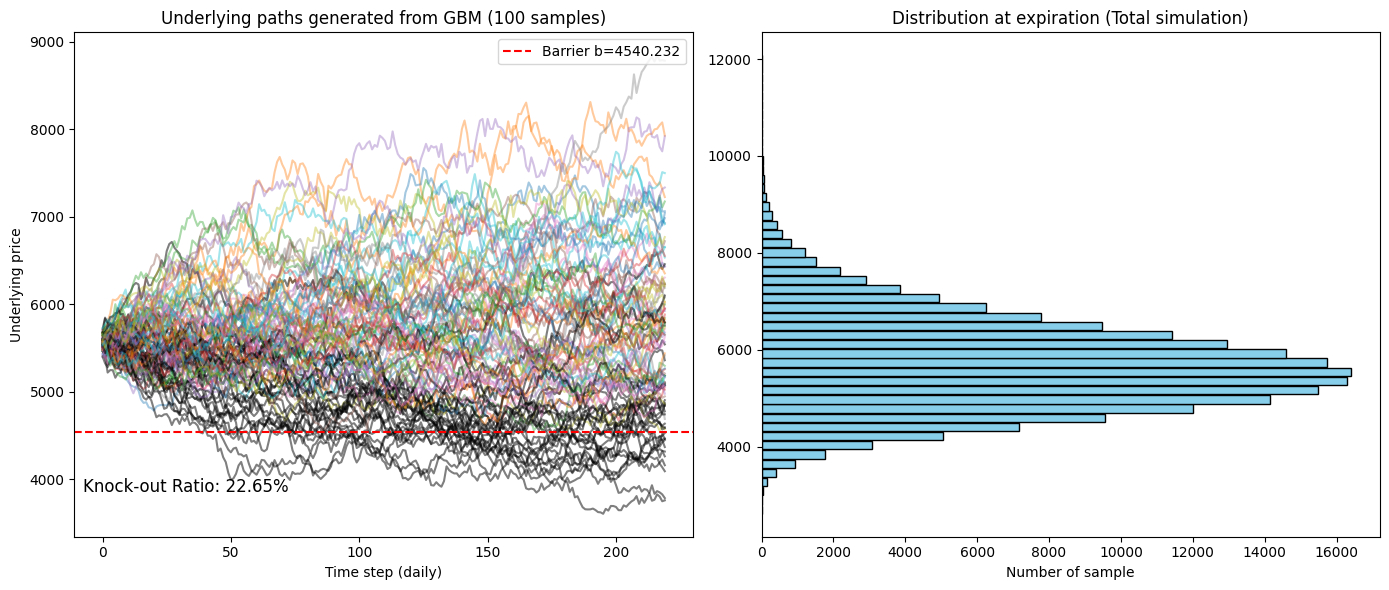

In [5]:
np.random.seed(42)
idx_sample = np.random.choice(GBMpath.shape[0], size=100, replace=False)
GBM_sample = GBMpath[idx_sample]

KO_mask_all = (GBMpath < b).any(axis=1)
KOratio = KO_mask_all.mean()
sample_KO_mask = (GBM_sample < b).any(axis=1)

# 시각화
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for i, path in enumerate(GBM_sample):
    if sample_KO_mask[i]: axs[0].plot(path, color='black', alpha=0.5)
    else: axs[0].plot(path, alpha=0.4)

axs[0].axhline(b, color='red', linestyle='--', label=f'Barrier b={b}')
axs[0].legend(loc='upper right')
axs[0].set_title('Underlying paths generated from GBM (100 samples)')
axs[0].set_xlabel('Time step (daily)')
axs[0].set_ylabel('Underlying price')

axs[0].text(
    x=m * 0.33, y=b * 0.85,
    s=f'Knock-out Ratio: {KOratio:.2%}',
    color='black', fontsize=12, ha='right'
)

final_prices = GBMpath[:, -1]
n_bins = 50
counts, bins = np.histogram(final_prices, bins=n_bins)

axs[1].barh(
    y=(bins[:-1] + bins[1:]) / 2,
    width=counts, height=(bins[1] - bins[0]) * 0.9,
    align='center', color='skyblue', edgecolor='black'
)
axs[1].set_title('Distribution at expiration (Total simulation)')
axs[1].set_xlabel('Number of sample')

plt.tight_layout()
plt.show()

In [6]:
diff = abs(price-nxprice) / price
print(f"Difference ratio is : {diff:.4f}")

Difference ratio is : 0.0078


In [7]:
import QuantLib as ql

today = ql.Date(29, 4, 2025)
maturity = ql.Date(16, 3, 2026)
ql.Settings.instance().evaluationDate = today

payoff = ql.PlainVanillaPayoff(ql.Option.Put, k)
euExercise = ql.EuropeanExercise(maturity)
barrierOption = ql.BarrierOption(ql.Barrier.DownOut, b, rebate, payoff, euExercise)

spotHandle = ql.QuoteHandle(ql.SimpleQuote(s1))
flatRateTs = ql.YieldTermStructureHandle(ql.FlatForward(today, r, ql.Actual365Fixed()))
flatVolTs = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed()))
bsm = ql.BlackScholesProcess(spotHandle, flatRateTs, flatVolTs)

analyticBarrierEngine = ql.AnalyticBarrierEngine(bsm)
barrierOption.setPricingEngine(analyticBarrierEngine)
analytic_price = barrierOption.NPV() * np.exp(r*(t2-t1)) / s0 * notional

print(f"Analytic Price is : {analytic_price:.4f}")

Analytic Price is : 357.1444


:::